In [9]:
import pandas as pd
import sqlite3

# Conexión y Carga
conn = sqlite3.connect(':memory:')
df_Jr = pd.read_csv('manufacturing_defect_dataset.csv')

# Creamos el ID necesario para las funciones de ventana
df_Jr['id_proceso'] = df_Jr.index + 1
df_Jr.to_sql('manufacturing', conn, index=False, if_exists='replace')

# Función Maestra para agilizar
def ejecutar_analisis(titulo, query):
    print(f"\n {titulo}")
    return pd.read_sql_query(query, conn)
print("Columnas detectadas:", df_Jr.columns.tolist())


Columnas detectadas: ['ProductionVolume', 'ProductionCost', 'SupplierQuality', 'DeliveryDelay', 'DefectRate', 'QualityScore', 'MaintenanceHours', 'DowntimePercentage', 'InventoryTurnover', 'StockoutRate', 'WorkerProductivity', 'SafetyIncidents', 'EnergyConsumption', 'EnergyEfficiency', 'AdditiveProcessTime', 'AdditiveMaterialCost', 'DefectStatus', 'id_proceso']


In [29]:
# Validación rápida y necesaria
print(df_Jr.shape)
print(df_Jr.dtypes)
print(df_Jr.isnull().sum())

(3240, 18)
ProductionVolume          int64
ProductionCost          float64
SupplierQuality         float64
DeliveryDelay             int64
DefectRate              float64
QualityScore            float64
MaintenanceHours          int64
DowntimePercentage      float64
InventoryTurnover       float64
StockoutRate            float64
WorkerProductivity      float64
SafetyIncidents           int64
EnergyConsumption       float64
EnergyEfficiency        float64
AdditiveProcessTime     float64
AdditiveMaterialCost    float64
DefectStatus              int64
id_proceso                int64
dtype: object
ProductionVolume        0
ProductionCost          0
SupplierQuality         0
DeliveryDelay           0
DefectRate              0
QualityScore            0
MaintenanceHours        0
DowntimePercentage      0
InventoryTurnover       0
StockoutRate            0
WorkerProductivity      0
SafetyIncidents         0
EnergyConsumption       0
EnergyEfficiency        0
AdditiveProcessTime     0
AdditiveM

# **Niveles de Análisis**

### **Nivel 1: KPIS bases de manufactura**

In [27]:
query_n1 = """
SELECT
    COUNT(*) as total_registros,
    ROUND(AVG(DefectRate), 4) as tasa_defectos_promedio,
    ROUND(AVG(QualityScore), 2) as calidad_promedio,
    SUM(CASE WHEN DefectStatus = 1 THEN 1 ELSE 0 END) as total_defectuosos
FROM manufacturing;
"""
ejecutar_analisis("MÉTRICAS GLOBALES", query_n1)


 MÉTRICAS GLOBALES


,total_registros,tasa_defectos_promedio,calidad_promedio,total_defectuosos
0,3240,2.7491,80.13,2723


### **Nivel 2: Funciones de Window (Ranking y Variaciones)**

In [19]:
#Nivel 2A
query_n2a = """
SELECT
    rowid,
    QualityScore,
    ProductionVolume,
    RANK() OVER (ORDER BY QualityScore DESC) as rank_calidad,
    DENSE_RANK() OVER (ORDER BY QualityScore DESC) as dense_rank_calidad
FROM manufacturing
LIMIT 20;

"""
ejecutar_analisis("ANÁLISIS DE FLUJO Y ACUMULADOS", query_n2a)


 ANÁLISIS DE FLUJO Y ACUMULADOS


,rowid,QualityScore,ProductionVolume,rank_calidad,dense_rank_calidad
0,1853,99.996993,515,1,1
1,1205,99.992206,421,2,2
2,1380,99.978363,194,3,3
3,2907,99.965983,902,4,4
4,2842,99.945915,755,5,5
5,1180,99.930759,761,6,6
6,2348,99.926990,615,7,7
7,1524,99.915388,212,8,8
8,185,99.907849,663,9,9
9,2409,99.892824,990,10,10


In [20]:
#Nivel 2B
query_n2b = """
SELECT
    id_proceso,
    ProductionVolume,
    COALESCE(LAG(ProductionVolume, 1) OVER (ORDER BY id_proceso), 0) as vol_anterior,
    ProductionVolume - COALESCE(LAG(ProductionVolume, 1) OVER (ORDER BY id_proceso), 0) as variacion,
    SUM(ProductionVolume) OVER (ORDER BY id_proceso ROWS UNBOUNDED PRECEDING) as prod_acumulada
FROM manufacturing
LIMIT 20
;
"""
ejecutar_analisis("ANÁLISIS DE FLUJO Y ACUMULADOS", query_n2b)


 ANÁLISIS DE FLUJO Y ACUMULADOS


,id_proceso,ProductionVolume,vol_anterior,variacion,prod_acumulada
0,1,202,0,202,202
1,2,535,202,333,737
2,3,960,535,425,1697
3,4,370,960,-590,2067
4,5,206,370,-164,2273
5,6,171,206,-35,2444
6,7,800,171,629,3244
7,8,120,800,-680,3364
8,9,714,120,594,4078
9,10,221,714,-493,4299


In [21]:
#Nivel 2c: Acumulado de producción
query_n2c = """
SELECT
    rowid,
    ProductionVolume,
    SUM(ProductionVolume) OVER (
        ORDER BY rowid
        ROWS UNBOUNDED PRECEDING
    ) as produccion_acumulada
FROM manufacturing;
"""
ejecutar_analisis("ANÁLISIS DE FLUJO Y ACUMULADOS", query_n2c)


 ANÁLISIS DE FLUJO Y ACUMULADOS


,rowid,ProductionVolume,produccion_acumulada
0,1,202,202
1,2,535,737
2,3,960,1697
3,4,370,2067
4,5,206,2273
...,...,...,...
3235,3236,762,1775388
3236,3237,335,1775723
3237,3238,835,1776558
3238,3239,302,1776860


### **Nivel 3: Identificación de Anomalías (CTE)**

In [24]:
query_n3 = """
WITH defectos_rankeados AS (
    SELECT
        rowid,
        DefectRate,
        QualityScore,
        ProductionVolume,
        ROW_NUMBER() OVER (ORDER BY DefectRate DESC) as rn
    FROM manufacturing
),
sobre_promedio AS (
    SELECT *
    FROM manufacturing
    WHERE DefectRate > (SELECT AVG(DefectRate) FROM manufacturing)
)
SELECT * FROM defectos_rankeados WHERE rn = 1;
"""
ejecutar_analisis("CASOS CRÍTICO", query_n3)


 CASOS CRÍTICO


,rowid,DefectRate,QualityScore,ProductionVolume,rn
0,424,4.998529,85.092979,611,1


In [25]:
#Desviación de calidad
query_cte_promedio = """
WITH promedio_global AS (
    SELECT AVG(DefectRate) as avg_rate FROM manufacturing
)
SELECT
    m.id_proceso,
    m.DefectRate,
    m.QualityScore
FROM manufacturing m, promedio_global p
WHERE m.DefectRate > p.avg_rate
ORDER BY m.DefectRate DESC;
"""
ejecutar_analisis("ANÁLISIS DE DESVIACIÓN DE CALIDAD (CTE)", query_cte_promedio)


 ANÁLISIS DE DESVIACIÓN DE CALIDAD (CTE)


,id_proceso,DefectRate,QualityScore
0,424,4.998529,85.092979
1,974,4.997008,74.290837
2,2527,4.994802,92.522048
3,1132,4.994375,66.405130
4,1879,4.994143,69.960798
...,...,...,...
1600,325,2.754362,98.264023
1601,1857,2.753399,92.220124
1602,1812,2.752227,86.406906
1603,2789,2.750416,97.871591


# **Preguntas de negocio**

### **Nivel 1:**
---


- ¿Cuál es la tasa de defectos promedio global?

**Respuesta:** La tasa de defectos promedio global es de 2.7491 con una calidad promedio de 80.13 % . Se sugiere implementar un estudio de metodos y tiempo, así como un control de la calidad para minimizar la variabilidad del proceso y aspirar al 82%.

- ¿Qué registros tienen `DefectStatus = 1` (defectuoso)?

**Respuesta:** La cantidad de productos defectuosos son 2723 productos por lo que se debe hacer un control estadistico de la calidad al proceso para saber porque estan ocurriendo estas no conformidades, y saber si el proceso está en control.

### **Nivel 2:**
---



- Ranking de registros por `QualityScore` — ¿quién lidera? (RANK)

**Respuesta:** Los que lideran por el puntaje de calidad son los siguientes números ID de fila. Con un puntaje de calidad del 99.9% lo cual denota una baja variabilidad en el proceso.

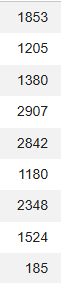




- Comparación día a día de `ProductionVolume` — ¿subió o bajó respecto al registro anterior? (LAG)+}

**Respuesta:** Respecto al registro anterior el volumén de producción fue variable, por ejemplo en el Id de proceso 8 respecto al anterior produjo 120 siendo 680 menos que el día anterior, pero en el id proceso 7 produjo 629 más que el proceso anterior, lo que denota la variabilidad de los procesos.

- Acumulado de `ProductionVolume` ordenado por registro (SUM OVER)

**Respuesta:** El acumulado del volumen de producción total global es de 1777215

### **Nivel 3:**
---

**Nivel 3:**
- Top 1 registro por nivel de `DefectRate` usando ROW_NUMBER + CTE

**Respuesta:** El top 1 registro por es el número de fila 424, con una tasa de 5 defectos
- Identificar registros donde `DefectRate` supera el promedio histórico del dataset
Los registros son los siguientes rowid, en donde tienen la misma tasa de 5 defectos

 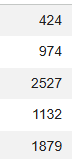



In [26]:
# Exportar queries a un archivo .sql
queries_sql = f"""-- ==========================================
-- SCRIPT DE ANÁLISIS DE MANUFACTURA Y CALIDAD
-- Autor: Joshuar Enrique Rodriguez Moreno
-- ==========================================

-- NIVEL 1: KPIs Globales
{query_n1}

-- NIVEL 2A: Ranking de Calidad
{query_n2a}

-- NIVEL 2B: Análisis de Flujo y Acumulados (Variación LAG)
{query_n2b}

-- NIVEL 2C: Producción Acumulada
{query_n2c}

-- NIVEL 3: Casos Críticos (CTE y Subconsultas)
{query_n3}

-- NIVEL 3B: Análisis de Desviación de Calidad
{query_cte_promedio}
"""

with open('queries_avanzadas.sql', 'w') as file:
    file.write(queries_sql)

print("Archivo 'queries_avanzadas.sql' generado exitosamente. Listo para descargar.")

Archivo 'queries_avanzadas.sql' generado exitosamente. Listo para descargar.
